---

<h1><center>ENGIN178 Final Project<br><br> Group 14 </center></h1>

---
This project is designed to take blended body delta wing aircraft positional state given in yaw angle, pitch angle, as well as the absolute and relative degree of elevon and map that to aerodynamic force and moment coefficients to be used in a controller.

+ Load the data
+ Split the data into training, validation, and testing datasets
+ Normalize the data
+ Organize the data into input sequences and output values
+ Train these models
    + Linear regression
    + Multi-layer perceptron (a.k.a. dense neural network)
    + simple RNN
    + LSTM
+ Compare the models
+ Compute performance of the best model

In [1]:
#importing dependencies (Copied from HW4)
import os
import random
import numpy as np
import pandas as pd
from pandas.core.indexes.datetimes import DatetimeIndex
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import joblib
#from resources.hashutils import *
os.environ['PYTHONHASHSEED'] = '0'  # optional, for hash-based functions
#random.seed(2434)
#np.random.seed(2434)
#torch.manual_seed(2434)
#torch.use_deterministic_algorithms(True)
np.set_printoptions(precision=4)

def predict_model(model, x):
    model.eval()
    x_tensor = torch.tensor(np.asarray(x), dtype=torch.float32)
    with torch.no_grad():
        yhat = model(x_tensor).detach().cpu().numpy()
    return yhat

def predict_any(model, x):
    if isinstance(model, nn.Module):
        return predict_model(model, x)
    return model.predict(x)

# Step 0: Shuffle the Rows of Our Data

This step is necessary becasue the csv is data that was generated by VspAero is organized in the angle of attack sweeps meaning that if we were to split this base csv into training, validation, and test data we would be missing ebtire sweeps in the training. To remedy this the rows of the csv need to be randomly shuffled to ensure an even distribution of the different cfd sweeps.

This 

In [4]:
# if still need to shuffle data
unshuffledDat = pd.read_csv('aero_autosweep.csv')
#unshuffledDatNew =unshuffledDat.drop('source_file', axis=1)
shuffledDat = unshuffledDat .sample(frac=1, random_state = 31).reset_index(drop=True)
shuffledDat.to_csv('shuffledAutoSweep.csv', index=False)

In [ ]:
# if the shuffle has alreday been done just run this 
shuffledDat = pd.read_csv('shuffledAutoSweep.csv')

# Step 1: Split the Data Intro Train, Test, and Validation Data Sets


In [5]:
# create the function that will split our data up into train, validate, and test lists. pt indicates percent train, pv 
# indicates percent validate... please use float

def splitData(pt,pv):

    assert(pt>=0)
    assert(pv>=0)
    assert(pt+pv<=1)

    N = shuffledDat.shape[0]

    train_end = int(N*pt)
    val_end = train_end + int(N*pv)

    data_train = shuffledDat.copy().iloc[:train_end]
    data_validate = shuffledDat.copy().iloc[train_end:val_end]
    data_test = shuffledDat.copy().iloc[val_end:]
    
    #data_train = raw_data.sample(n=int(N*pt))
    #data_validate = raw_data.drop(data_train.index).sample(n=int(N*pv))
    #data_test = raw_data.drop(data_train.index).drop(data_validate.index)
    
    return data_train, data_validate, data_test

In [6]:

dataTrain, dataValidate, dataTest = splitData(0.70,0.10)

# Step 2: Split the Data into X and Y and Normalize

In [7]:
# normalize and scale the data using StandardScaler() method from scikit learn
from sklearn.preprocessing import StandardScaler

xScaler = StandardScaler()
yScaler = StandardScaler()

xTrain = dataTrain[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yTrain = dataTrain[["CL","CD","CY","Cl","Cm","Cn"]]

xValidate = dataValidate[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yValidate = dataValidate[["CL","CD","CY","Cl","Cm","Cn"]]

xTest = dataTest[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yTest = dataTest[["CL","CD","CY","Cl","Cm","Cn"]]

xTrainScaled = xScaler.fit_transform(xTrain)
xTestScaled = xScaler.transform(xTrain)
xValidateScaled = xScaler.transform(xValidate)

yTrainScaled = yScaler.fit_transform(yTrain)
yTestScaled = yScaler.transform(yTrain)
yValidateScaled = yScaler.transform(yValidate)

# Step 3: Build the MLP Model

In [8]:
torch.manual_seed(2434)

D = xTrainScaled.shape[1]

mlpModel = nn.Sequential( 
        nn.Linear(D, 64),
        nn.Tanh(),
        nn.Linear(64, 32),
        nn.Tanh(),
        nn.Linear(32, 16),
        nn.Tanh(),
        nn.Linear(16, 6)
        )

for layer in mlpModel:
    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)



# Step 4: Train the MLP Model

In [9]:
xTrainScaledTensor = torch.tensor(xTrainScaled, dtype=torch.float32)
yTrainScaledTensor = torch.tensor(yTrainScaled, dtype=torch.float32)

xValidateScaledTensor = torch.tensor(xValidateScaled, dtype=torch.float32)
yValidateScaledTensor = torch.tensor(yValidateScaled, dtype=torch.float32)

trainLoader = DataLoader(
    TensorDataset(xTrainScaledTensor, yTrainScaledTensor),
    batch_size=32,
    shuffle=True
)


In [10]:
from sklearn.metrics import mean_absolute_error

random.seed(2434)
torch.manual_seed(2434)

lossFunctionMLP = nn.MSELoss()
optimizerMLP = optim.Adam(mlpModel.parameters(), lr=0.001)

historyMLP = {
    "epoch": [],
    "trainMAE": [],
    "validateMAE": []
}

numEpochs = 500

for epoch in range(numEpochs):
    mlpModel.train()

    for xb, yb in trainLoader:
        optimizerMLP.zero_grad()

        yhatTrain = mlpModel(xb)   # shape: [batch_size, 6]
        loss = lossFunctionMLP(yhatTrain, yb)

        loss.backward()
        optimizerMLP.step()

    mlpModel.eval()

    with torch.no_grad():
        trainPredScaled = mlpModel(xTrainScaledTensor).cpu().numpy()
        validatePredScaled = mlpModel(xValidateScaledTensor).cpu().numpy()

    # Convert scaled predictions back to actual aero coefficient values
    trainPred = yScaler.inverse_transform(trainPredScaled)
    validatePred = yScaler.inverse_transform(validatePredScaled)

    yTrainActual = yScaler.inverse_transform(yTrainScaled)
    yValidateActual = yScaler.inverse_transform(yValidateScaled)

    trainMAE = mean_absolute_error(yTrainActual, trainPred)
    validateMAE = mean_absolute_error(yValidateActual, validatePred)

    historyMLP["epoch"].append(epoch)
    historyMLP["trainMAE"].append(trainMAE)
    historyMLP["validateMAE"].append(validateMAE)

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} | Train MAE: {trainMAE:.6f} | Validate MAE: {validateMAE:.6f}")

Epoch    0 | Train MAE: 0.021015 | Validate MAE: 0.020769
Epoch   50 | Train MAE: 0.002148 | Validate MAE: 0.002141
Epoch  100 | Train MAE: 0.001080 | Validate MAE: 0.001130
Epoch  150 | Train MAE: 0.000928 | Validate MAE: 0.000962
Epoch  200 | Train MAE: 0.001221 | Validate MAE: 0.001234
Epoch  250 | Train MAE: 0.000811 | Validate MAE: 0.000804
Epoch  300 | Train MAE: 0.000709 | Validate MAE: 0.000731
Epoch  350 | Train MAE: 0.000755 | Validate MAE: 0.000765
Epoch  400 | Train MAE: 0.000819 | Validate MAE: 0.000831
Epoch  450 | Train MAE: 0.001161 | Validate MAE: 0.001203


In [11]:
coefNames = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

validateMAEEach = mean_absolute_error(
    yValidateActual,
    validatePred,
    multioutput="raw_values"
)

for name, mae in zip(coefNames, validateMAEEach):
    print(f"{name}: {mae:.6f}")

CL: 0.003379
CD: 0.000266
CY: 0.000081
Cl: 0.000244
Cm: 0.001676
Cn: 0.000030


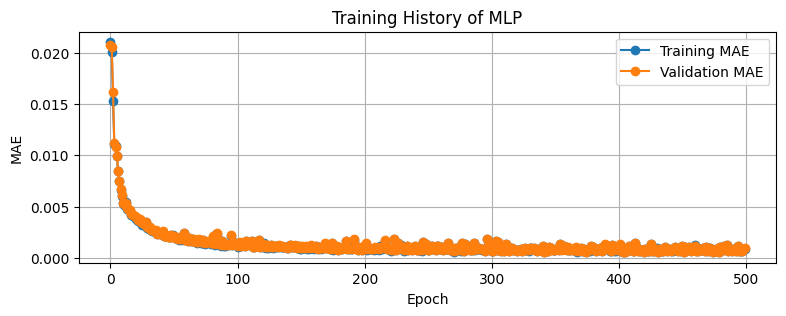

In [12]:
numEpochs = len(historyMLP["epoch"])

plt.figure(figsize=(9, 3))
plt.plot(historyMLP["epoch"], historyMLP["trainMAE"], marker="o", label="Training MAE")
plt.plot(historyMLP["epoch"], historyMLP["validateMAE"], marker="o", label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training History of MLP")
plt.legend()
plt.grid(True)
plt.show()

# Step 5: Evaluate the Model

In [13]:
# Convert test data to tensors
xTestScaledTensor = torch.tensor(xTestScaled, dtype=torch.float32)

# Put model in evaluation mode
mlpModel.eval()

# Predict on test set
with torch.no_grad():
    testPredScaled = mlpModel(xTestScaledTensor).cpu().numpy()

# Convert predictions and true values back to actual aero coefficient values
testPred = yScaler.inverse_transform(testPredScaled)
yTestActual = yScaler.inverse_transform(yTestScaled)

# Overall test MAE across all 6 coefficients
testMAE = mean_absolute_error(yTestActual, testPred)

print(f"Test MAE: {testMAE:.6f}")

Test MAE: 0.000911


In [14]:
#coefNames = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

testMAEEach = mean_absolute_error(
    yTestActual,
    testPred,
    multioutput="raw_values"
)

for name, mae in zip(coefNames, testMAEEach):
    print(f"{name}: MAE = {mae:.6f}")

CL: MAE = 0.003209
CD: MAE = 0.000245
CY: MAE = 0.000078
Cl: MAE = 0.000234
Cm: MAE = 0.001671
Cn: MAE = 0.000029


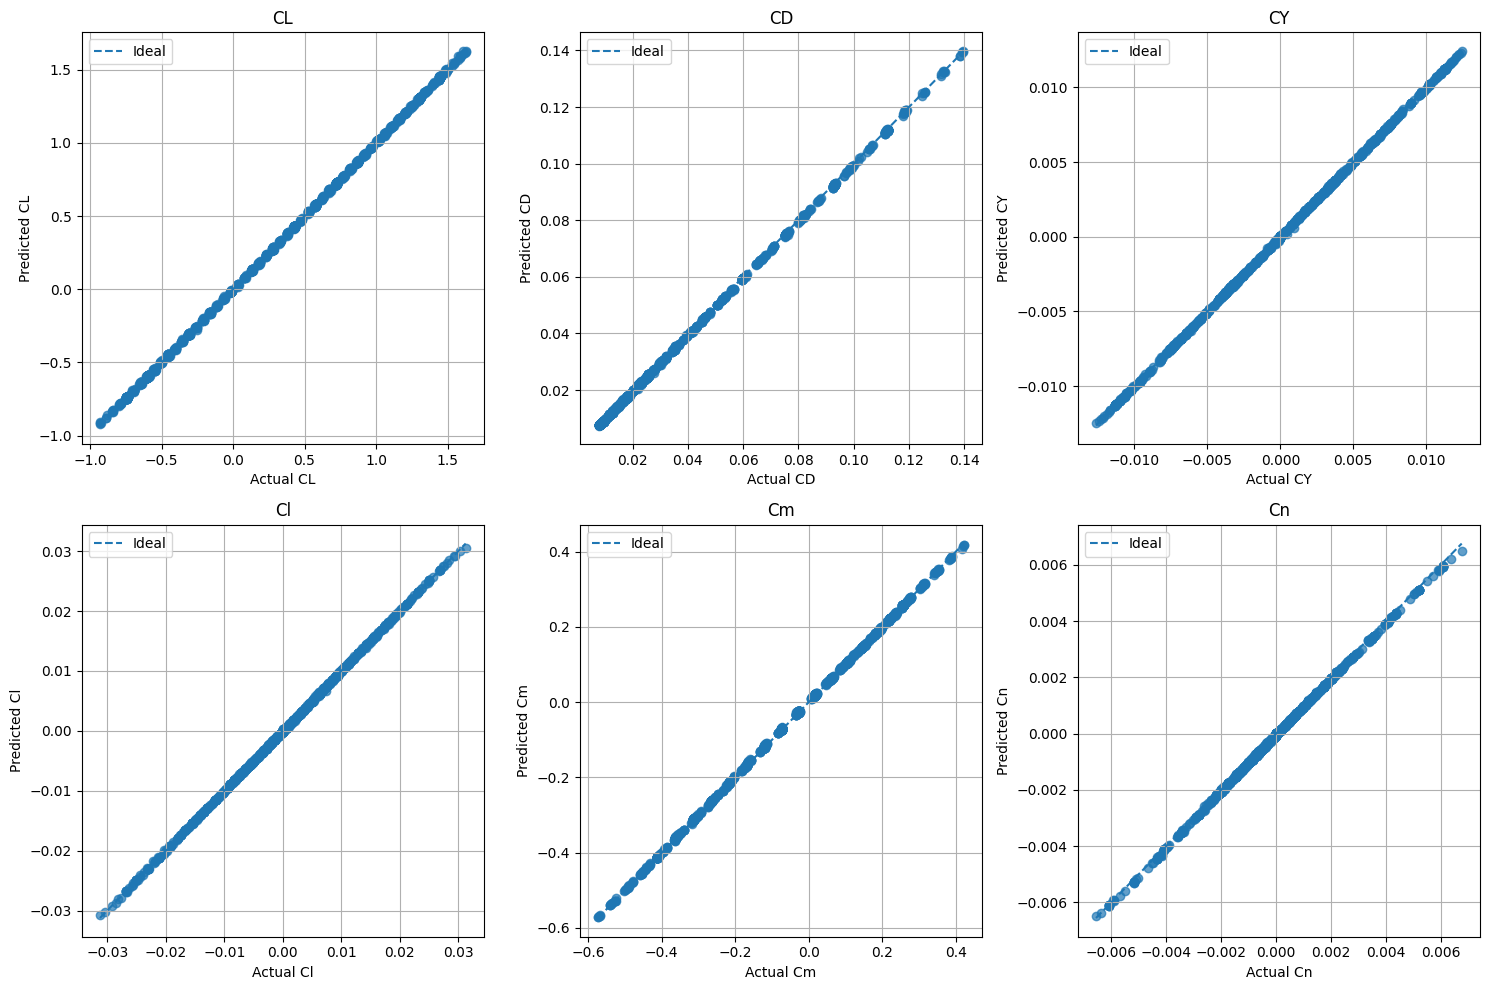

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, name in enumerate(coefNames):
    axes[i].scatter(yTestActual[:, i], testPred[:, i], alpha=0.7)

    minVal = min(yTestActual[:, i].min(), testPred[:, i].min())
    maxVal = max(yTestActual[:, i].max(), testPred[:, i].max())

    axes[i].plot([minVal, maxVal], [minVal, maxVal], linestyle="--", label="Ideal")
    axes[i].set_xlabel(f"Actual {name}")
    axes[i].set_ylabel(f"Predicted {name}")
    axes[i].set_title(name)
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

# Step 6: Save the Model to be Used Later

In [15]:
#torch.save(mlpModel, "mlp_aero_model.pt")
torch.save(mlpModel.state_dict(), "mlp_aero_state_dictV2.pt")
joblib.dump(xScaler, "xScalerV2.pkl")
joblib.dump(yScaler, "yScalerV2.pkl")

['yScalerV2.pkl']